# CLIP 图文检索 Demo

先用 CLIP 编码 1000 张图片并缓存向量；输入英文文本后，计算文本向量与图片向量的 cosine similarity，展示最相近的 5 张图片。这里不训练模型，也不使用 softmax。

流程：准备图片 → 加载预训练 CLIP → 编码并缓存图片 → 输入文本并检索。首次运行会下载约 94 MB 的 Imagenette 图片和 CLIP 模型。

## 1. 准备数据与目录

从 Imagenette 训练集的 10 个类别中，每类按固定随机种子抽取 100 张。图片、压缩包和特征缓存都留在项目目录中，方便后续运行复用。

In [8]:
from pathlib import Path
import torch
from PIL import Image

from clip_retrieval import ROOT, prepare_dataset

image_paths, image_manifest = prepare_dataset()


已准备 1000 张图片，来自 10 个类别。
运行设备：NVIDIA GeForce RTX 5070 Ti


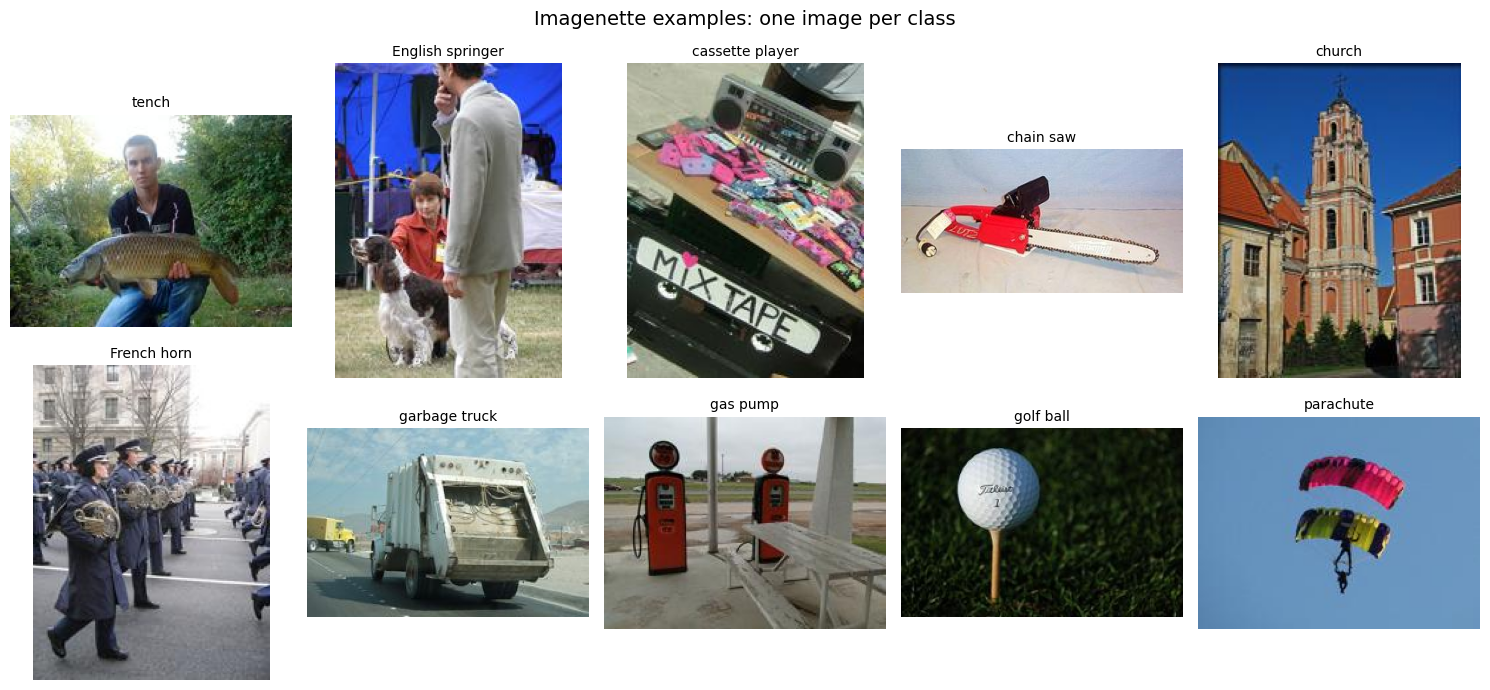

Displayed one example from each of 10 classes.


In [9]:
import matplotlib.pyplot as plt
from PIL import Image

class_names = {
    "n01440764": "tench",
    "n02102040": "English springer",
    "n02979186": "cassette player",
    "n03000684": "chain saw",
    "n03028079": "church",
    "n03394916": "French horn",
    "n03417042": "garbage truck",
    "n03425413": "gas pump",
    "n03445777": "golf ball",
    "n03888257": "parachute",
}

# Reuse the image list prepared in the previous cell and keep one image per class.
examples_by_class = {}
for image_path in image_paths:
    examples_by_class.setdefault(image_path.parent.name, image_path)

if len(examples_by_class) != 10:
    raise ValueError(f"Expected 10 classes, found {len(examples_by_class)}")

fig, axes = plt.subplots(2, 5, figsize=(15, 7))
for axis, (class_id, image_path) in zip(axes.flat, sorted(examples_by_class.items())):
    with Image.open(image_path) as image:
        axis.imshow(image.convert("RGB"))
    axis.set_title(class_names.get(class_id, class_id), fontsize=10)
    axis.axis("off")

fig.suptitle("Imagenette examples: one image per class", fontsize=14)
fig.tight_layout()
plt.show()
print(f"Displayed one example from each of {len(examples_by_class)} classes.")


## 2. 加载 CLIP 图文编码器

使用与 CLIP ViT-B/32 配套的 Processor 做图像预处理和文本分词。WSL 能访问 Hugging Face 时会自动下载模型；也可以在启动 Jupyter 前设置 CLIP_MODEL_PATH 指向已下载的模型目录。

In [10]:
from clip_retrieval import load_model

device, processor, model = load_model()


加载模型 /home/wuqiang/projects/CLIP-Retrieval-Demo/data/clip-vit-base-patch32 到 cuda…
模型已就绪；特征维度：512


## 3. 批量编码并缓存图片向量

模型将图片映射到 512 维空间。把每个向量除以它的 L2 范数后，向量点积就等于 cosine similarity。缓存同时记录模型标识和图片文件信息；它们改变时会重新编码。

In [11]:
from clip_retrieval import encode_image_gallery

image_features = encode_image_gallery(image_paths, image_manifest, device, processor, model)


已加载缓存：/home/wuqiang/projects/CLIP-Retrieval-Demo/cache/image_features.npz
图片特征矩阵：(1000, 512)；每行都是单位向量。


## 4. 输入文本并查看 Top-5

Query 使用英文，因为标准 CLIP 主要针对英文图文训练。修改 query 变量后重新运行本单元格即可；空文本会给出提示。

1. data/imagenette2-160/train/n02102040/n02102040_1103.JPEG  cosine similarity = 0.2821
2. data/imagenette2-160/train/n02102040/n02102040_2565.JPEG  cosine similarity = 0.2775
3. data/imagenette2-160/train/n02102040/n02102040_6124.JPEG  cosine similarity = 0.2759
4. data/imagenette2-160/train/n02102040/n02102040_4779.JPEG  cosine similarity = 0.2754
5. data/imagenette2-160/train/n02102040/n02102040_2039.JPEG  cosine similarity = 0.2730


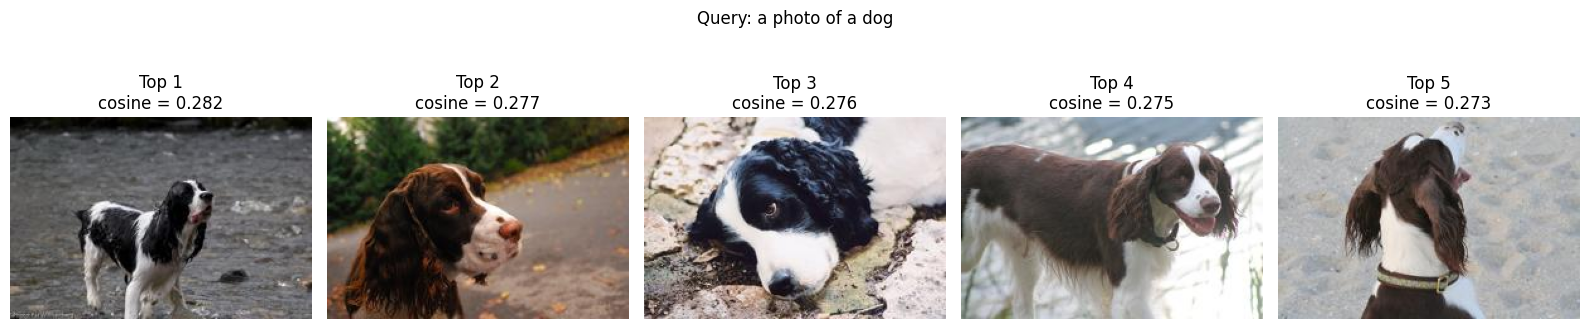

In [12]:
from clip_retrieval import encode_texts, rank_queries

def search(query: str, top_k: int = 5) -> list[dict]:
    query = query.strip()
    if not query:
        raise ValueError("Query 不能为空，请输入一段英文描述。")
    if not 1 <= top_k <= len(image_paths):
        raise ValueError(f"top_k 必须在 1 到 {len(image_paths)} 之间。")

    global _last_text_features
    _last_text_features = encode_texts([query], device, processor, model)
    return rank_queries([query], image_features, image_paths, device, processor, model, top_k=top_k)[0]


def show_results(query: str, results: list[dict]) -> None:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, len(results), figsize=(16, 4))
    if len(results) == 1:
        axes = [axes]
    for rank, (axis, result) in enumerate(zip(axes, results), start=1):
        with Image.open(result["path"]) as image:
            axis.imshow(image.convert("RGB"))
        axis.set_title(f"Top {rank}\ncosine = {result['score']:.3f}")
        axis.axis("off")
    fig.suptitle(f"Query: {query}")
    fig.tight_layout()
    plt.show()


query = "a photo of a dog"  # 也可以试试：a church、a parachute
if query.strip():
    results = search(query, top_k=5)
    for rank, result in enumerate(results, start=1):
        print(f"{rank}. {result['path'].relative_to(ROOT)}  cosine similarity = {result['score']:.4f}")
    show_results(query, results)
else:
    print("Query 不能为空，请设置 query 后重试。")


## 5. 检查相似度与缓存

下面直接计算 cosine similarity，与归一化向量的点积对照。再执行一次图片编码单元格，应显示加载缓存；更改 Query 只会重新计算文本向量与相似度。

In [13]:
if query.strip():
    top_result = results[0]
    image_index = image_paths.index(top_result["path"])
    text_vector = _last_text_features
    direct_cosine = torch.nn.functional.cosine_similarity(
        image_features[image_index].unsqueeze(0), text_vector
    ).item()
    dot_product = (image_features[image_index] @ text_vector.squeeze(0)).item()
    print(f"直接计算的 cosine similarity：{direct_cosine:.6f}")
    print(f"归一化向量的点积：         {dot_product:.6f}")
    assert abs(direct_cosine - dot_product) < 1e-5
    assert abs(dot_product - top_result["score"]) < 1e-5
    print("一致：点积结果就是 cosine similarity。")

直接计算的 cosine similarity：0.282055
归一化向量的点积：         0.282055
一致：点积结果就是 cosine similarity。


## 6. Ground truth 检索评测

运行固定 100 条逐图描述的评测集。Recall@K 是目标图片进入前 K 名的 query 比例；MRR 是目标排名倒数的平均值；单目标 nDCG 为 1/log₂(rank+1)，nDCG@10 对第 10 名之后的目标计 0。下面各展示一条目标恰好排第 1、3、5 名的命中示例，以及最多 5 条 Top-5 未命中示例。每条 query 只标注一张目标图，因此可能把语义正确的同类图片视为未命中。


Queries: 100 | Gallery: 1000 images
Recall@1: 0.2600 (26.0%)
Recall@5: 0.5200 (52.0%)
Recall@10: 0.6200 (62.0%)
MRR: 0.3844 (38.4%)
NDCG: 0.5090 (50.9%)
NDCG@10: 0.4278 (42.8%)
Top-1 命中示例：q001 | An older man in sunglasses sits in tall grass while holding a small golden fish on a line.
Top-3 命中示例：q030 | A car cassette stereo and air vents fill the frame in a close-up dashboard view.
Top-5 命中示例：q011 | A small black and white spaniel stands on a wooden floor and looks upward.


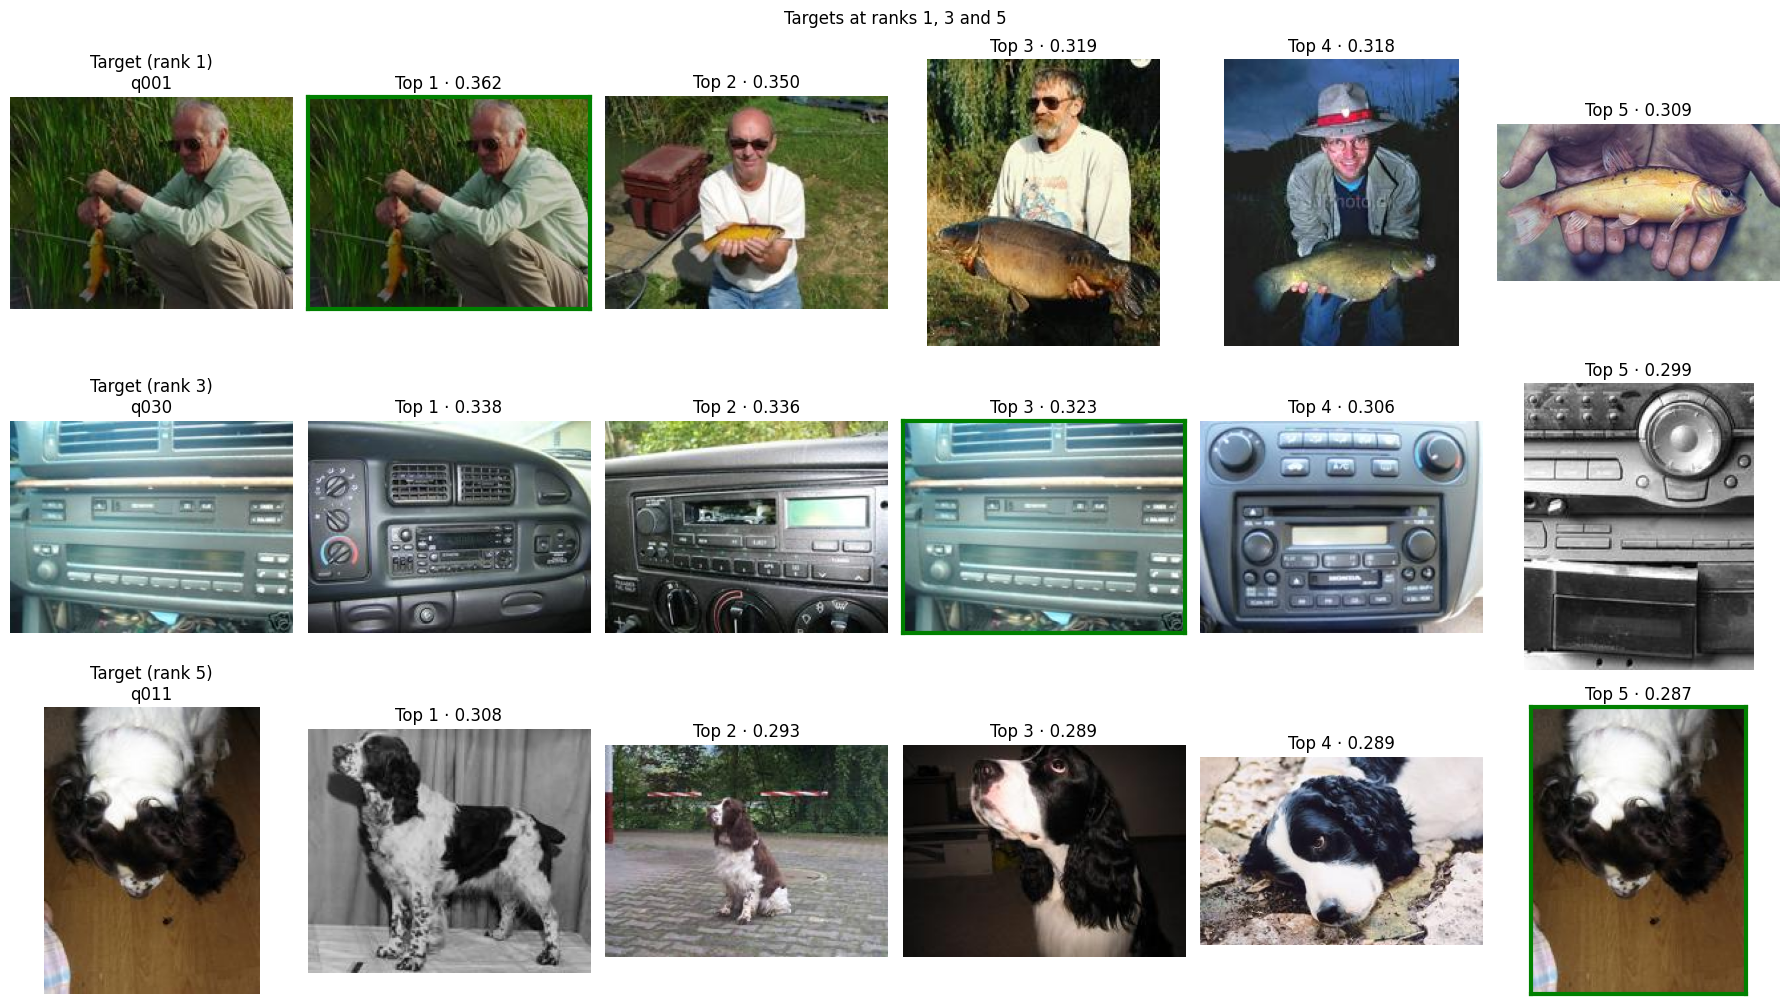

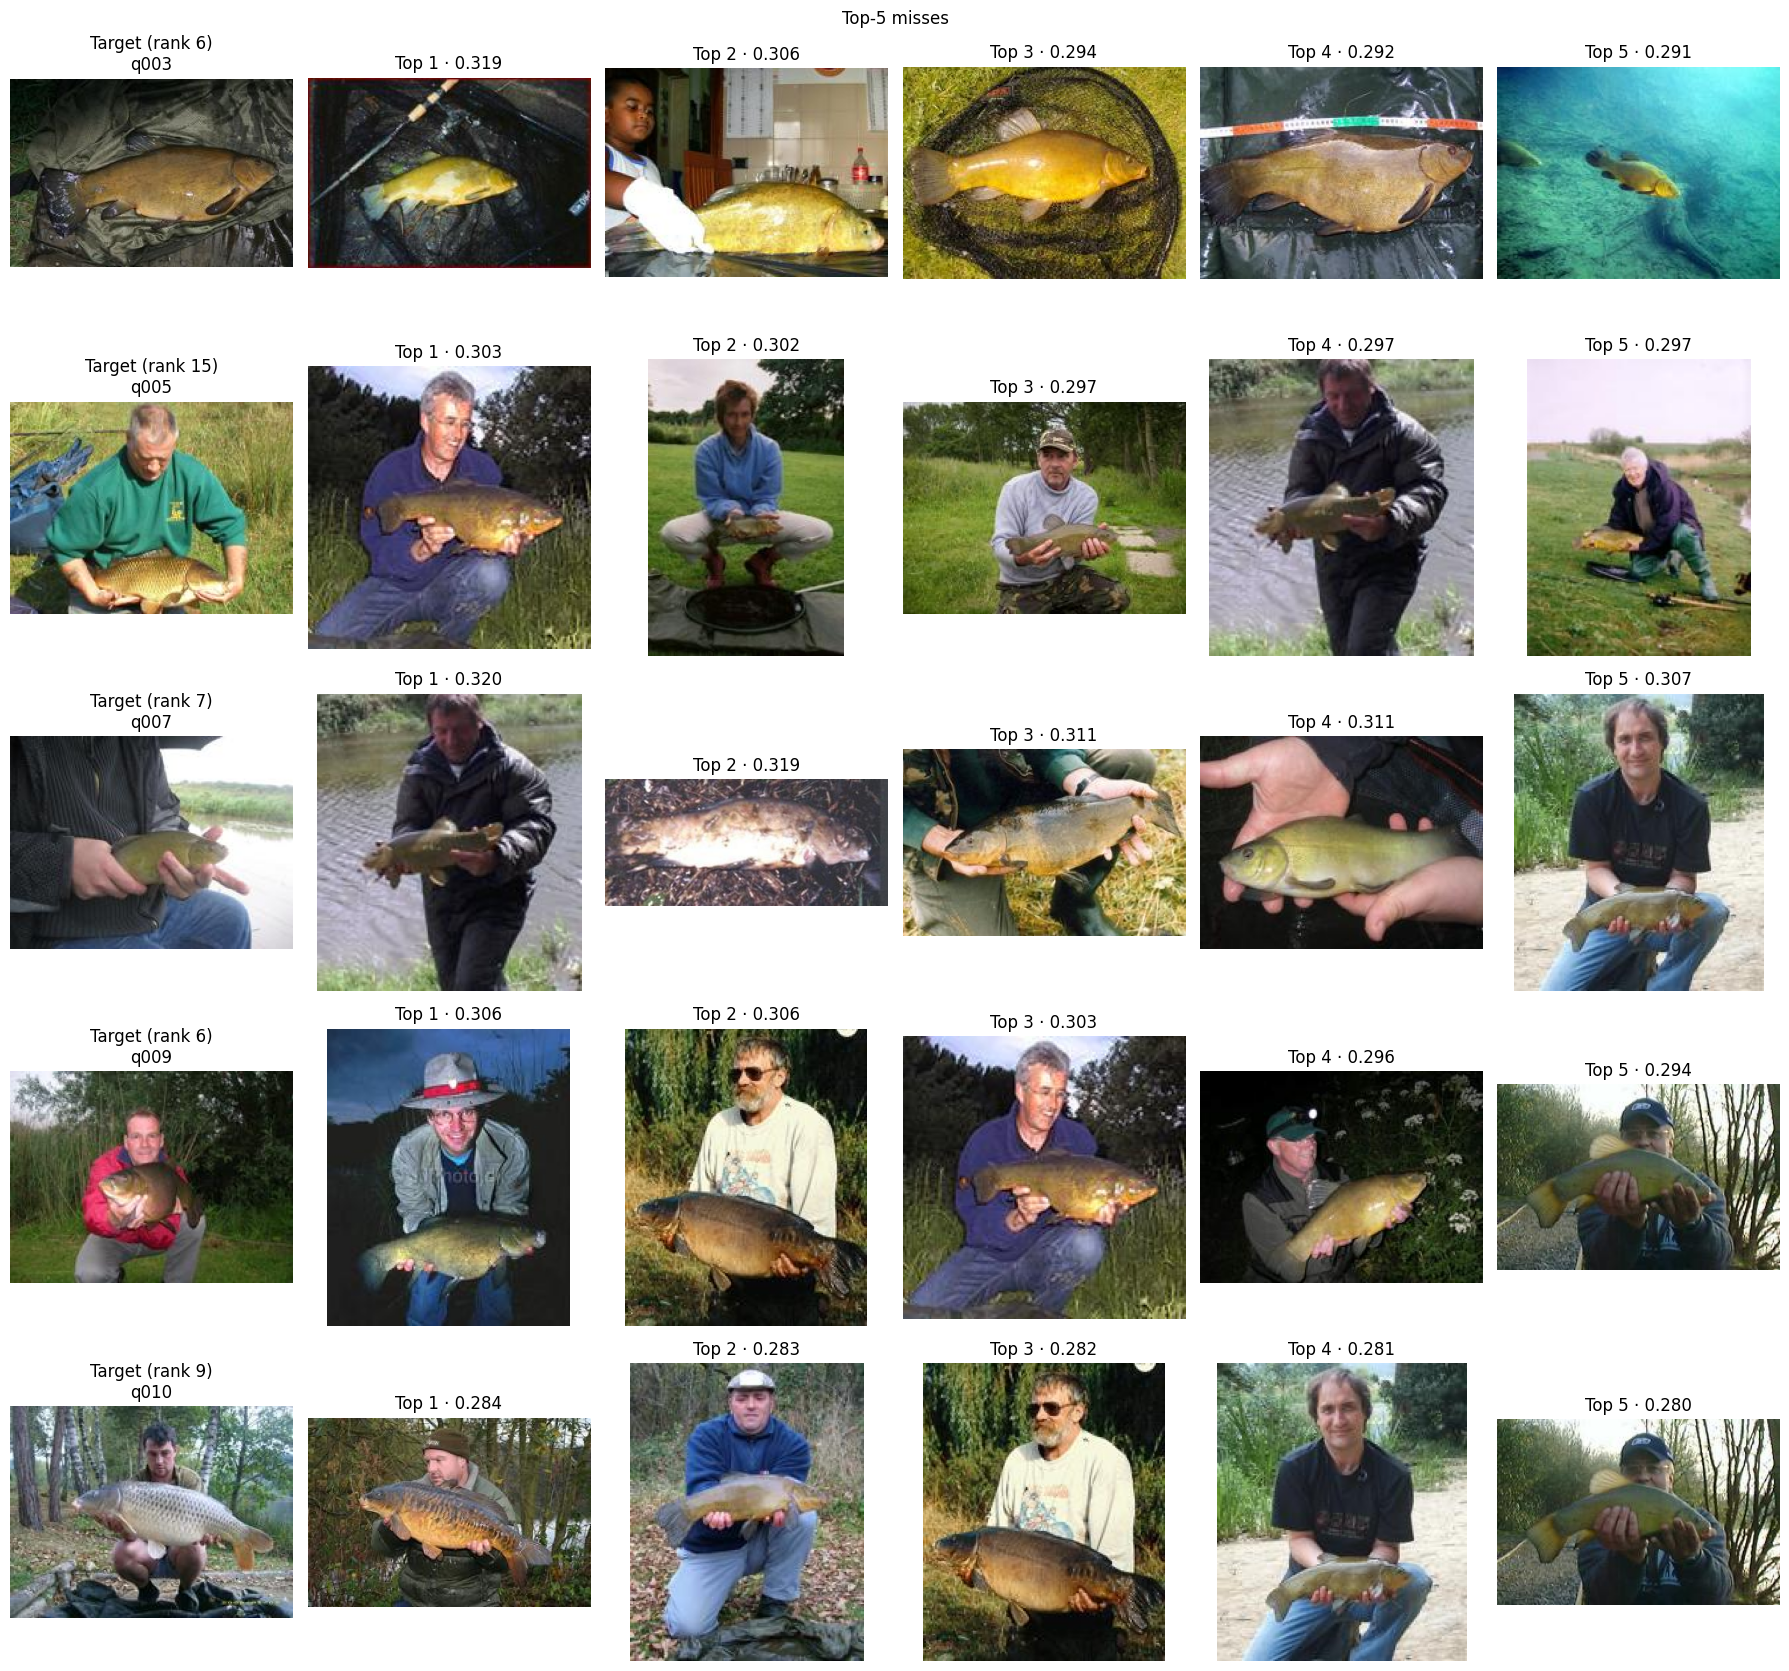

In [17]:
import json
import matplotlib.pyplot as plt
from clip_retrieval import evaluate_rankings, rank_queries, validate_ground_truth

GROUND_TRUTH_PATH = ROOT / "evaluation" / "ground_truth.json"
ground_truth = validate_ground_truth(json.loads(GROUND_TRUTH_PATH.read_text(encoding="utf-8")), image_manifest)
full_rankings = rank_queries(
    [item["query"] for item in ground_truth], image_features, image_paths,
    device, processor, model, top_k=len(image_paths),
)
evaluation_metrics, evaluation_rows = evaluate_rankings(ground_truth, full_rankings, image_manifest)
print(f"Queries: {len(evaluation_rows)} | Gallery: {len(image_manifest)} images")
for name, value in evaluation_metrics.items():
    label = "MRR" if name == "reciprocal_rank" else name.upper().replace("RECALL", "Recall")
    print(f"{label}: {value:.4f} ({value:.1%})")


def show_evaluation_examples(rows, title):
    if not rows:
        print(f"{title}：没有符合条件的样本。")
        return

    fig, axes = plt.subplots(len(rows), 6, figsize=(18, 3.4 * len(rows)), squeeze=False)
    fig.suptitle(title)
    for row_index, row in enumerate(rows):
        with Image.open(ROOT / row["image_path"]) as image:
            axes[row_index, 0].imshow(image.convert("RGB"))
        axes[row_index, 0].set_title(f"Target (rank {row['rank']})\n{row['query_id']}")
        axes[row_index, 0].set_ylabel(row["query"], wrap=True, fontsize=8)
        axes[row_index, 0].axis("off")

        for rank, result in enumerate(row["top10"][:5], start=1):
            axis = axes[row_index, rank]
            with Image.open(result["path"]) as image:
                axis.imshow(image.convert("RGB"))
            axis.set_title(f"Top {rank} · {result['score']:.3f}")
            axis.set_xticks([])
            axis.set_yticks([])
            if rank == row["rank"]:
                for spine in axis.spines.values():
                    spine.set_edgecolor("green")
                    spine.set_linewidth(3)
            else:
                axis.axis("off")
    fig.tight_layout()
    plt.show()


hit_examples = []
for target_rank in (1, 3, 5):
    row = next((row for row in evaluation_rows if row["rank"] == target_rank), None)
    if row is None:
        print(f"没有目标恰好排第 {target_rank} 名的示例。")
    else:
        hit_examples.append(row)
        print(f"Top-{target_rank} 命中示例：{row['query_id']} | {row['query']}")
show_evaluation_examples(hit_examples, "Targets at ranks 1, 3 and 5")

misses = [row for row in evaluation_rows if row["rank"] > 5][:5]
show_evaluation_examples(misses, "Top-5 misses")
